# 4.2 - Weight Aligning

After each task, rescale the new-class classifier rows so their average magnitude
matches the old classes.

Memory: 0 bytes.

## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "xx"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Drive mounted.
Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
ULAL_DATASET_ROOT = /kaggle/input/ucf101-action-recognition/
ULAL_OUTPUT_ROOT  = /kaggle/working/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Preprocess data**

In [5]:
# BASE
cfg.OUTPUT_ROOT = cfg.BASE_ROOT
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.SELECTED_CLASSES)

# TASK 1
cfg.OUTPUT_ROOT = cfg.TASK1_ROOT
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_1)

# TASK 2
cfg.OUTPUT_ROOT = cfg.TASK2_ROOT
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_2)


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /content/UCF101/grouped_base
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_base

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /content/UCF101/grouped_task1
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /content/UCF101/grouped_task2
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task2


In [6]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [7]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling']


In [8]:
# The cache fixes the label space, so it is built once here for all tasks.
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BandMarching': 15, 'BlowDryHair': 16, 'BlowingCandles': 17, 'BodyWeightSquats': 18, 'Bowling': 19, 'BoxingPunchingBag': 20, 'BoxingSpeedBag': 21, 'BrushingTeeth': 22, 'CliffDiving': 23, 'CricketBowling': 24, 'CricketShot': 25, 'CuttingInKitchen': 26, 'FieldHockeyPenalty': 27, 'Haircut': 28, 'SoccerPenalty': 29}


## **Create Loaders**

In [9]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)
check_cache_labels(META, ALL_CLASSES_LIST)

TASK_CLASSES = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
TASK_ROOTS   = [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]
TASK_NAMES   = ["Base", "Task1", "Task2"]

base_test_loader  = emb_loaders(CACHE, [0], "test")[1]
task1_test_loader = emb_loaders(CACHE, [1], "test")[1]
task2_test_loader = emb_loaders(CACHE, [2], "test")[1]

combined_test_loader  = emb_loaders(CACHE, [0, 1], "test")[1]
combined_test_loader2 = emb_loaders(CACHE, [0, 1, 2], "test")[1]

base_train,  base_y   = task_split(CACHE, 0, "train")
base_val,    base_vy  = task_split(CACHE, 0, "val")
task1_train, task1_y  = task_split(CACHE, 1, "train")
task1_val,   task1_vy = task_split(CACHE, 1, "val")
task2_train, task2_y  = task_split(CACHE, 2, "train")
task2_val,   task2_vy = task_split(CACHE, 2, "val")

print(f"base  test {len(base_test_loader.dataset)}")
print(f"task1 test {len(task1_test_loader.dataset)}")
print(f"task2 test {len(task2_test_loader.dataset)}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)
base  test 212
task1 test 217
task2 test 226


## **Upload Model**

In [10]:
ARM_KEY  = "weight_align"
ARM_NAME = "WeightAlign"
ARM_CONFIG = {"mechanism": "weight_align"}

CL_EPOCHS, CL_LR, CL_WD, CL_BATCH, CL_LS = 15, 5e-4, 0.03, 32, 0.10

head_base = load_or_train_base_head(
    f"{cfg.CKPT_DIR}/head_base.pt", CACHE, LSTM_STATE, len(cfg.SELECTED_CLASSES), device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
)

Loaded base head <- /content/drive/MyDrive/apai/checkpoints/head_base.pt


In [11]:
head_task1 = expand_head(copy.deepcopy(head_base), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1))
model_task1 = ModelWrapper(head_task1).to(device)

In [12]:
results_baseline = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.9009  Loss=0.9683
  task1_only       -> Acc=0.0184  Loss=3.1715
  combined_t1      -> Acc=0.4545  Loss=2.0827


In [13]:
print(f"head_task1 classifier: in={head_task1.classifier.in_features}  out={head_task1.classifier.out_features}")

head_task1 classifier: in=256  out=20


## **Task One**

In [14]:
set_seed(cfg.SEED)

head_task1, train_task1 = train_task(
    head_task1, task1_train, task1_y, task1_val, task1_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    
    tag=ARM_KEY,
)
model_task1 = ModelWrapper(head_task1).to(device)

head_task1 = weight_align(head_task1, n_old=len(cfg.SELECTED_CLASSES))
model_task1 = ModelWrapper(head_task1).to(device)

Epoch [1/15] | Train Acc: 0.6517 Loss: 1.5577 | Val Acc: 0.7778 Loss: 0.7932
  [weight_align] ep 01/15 | CE 1.5577
Epoch [2/15] | Train Acc: 0.9423 Loss: 0.7928 | Val Acc: 0.8431 Loss: 0.5958
Epoch [3/15] | Train Acc: 0.9808 Loss: 0.6873 | Val Acc: 0.8431 Loss: 0.6159
Epoch [4/15] | Train Acc: 0.9957 Loss: 0.6433 | Val Acc: 0.8824 Loss: 0.5570
Epoch [5/15] | Train Acc: 0.9989 Loss: 0.6272 | Val Acc: 0.8497 Loss: 0.6406
Epoch [6/15] | Train Acc: 1.0000 Loss: 0.6174 | Val Acc: 0.8758 Loss: 0.5835
Epoch [7/15] | Train Acc: 1.0000 Loss: 0.6111 | Val Acc: 0.8693 Loss: 0.6114
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.6100 | Val Acc: 0.8693 Loss: 0.5893
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.6090 | Val Acc: 0.8627 Loss: 0.5899
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.6079 | Val Acc: 0.8693 Loss: 0.6103
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.6072 | Val Acc: 0.8693 Loss: 0.6240
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.6066 | Val Acc: 0.8627 Loss: 0.6057
Epoch [13/15] | Train Acc: 1.0000 L

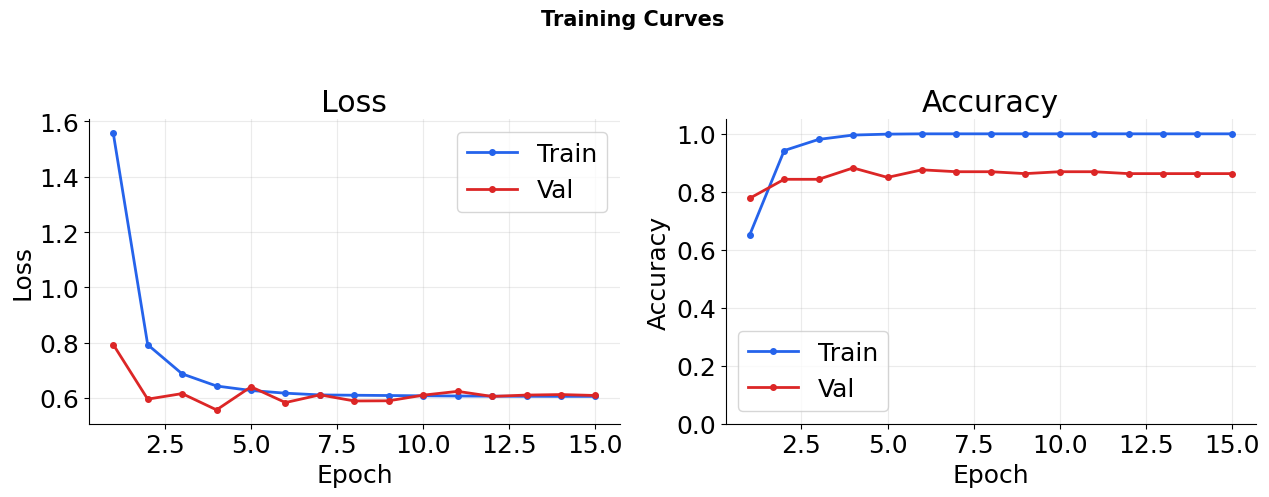

In [15]:
plot_training_results(train_task1)

In [16]:
results_after_t1 = evaluate_all_tasks(
    model            = model_task1,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader],
    combined_loaders = [combined_test_loader],
)

  base             -> Acc=0.0000  Loss=3.4040
  task1_only       -> Acc=0.9078  Loss=0.6708
  combined_t1      -> Acc=0.4592  Loss=2.0215


Running Inference on Test Set...


Test Accuracy: 0.4592


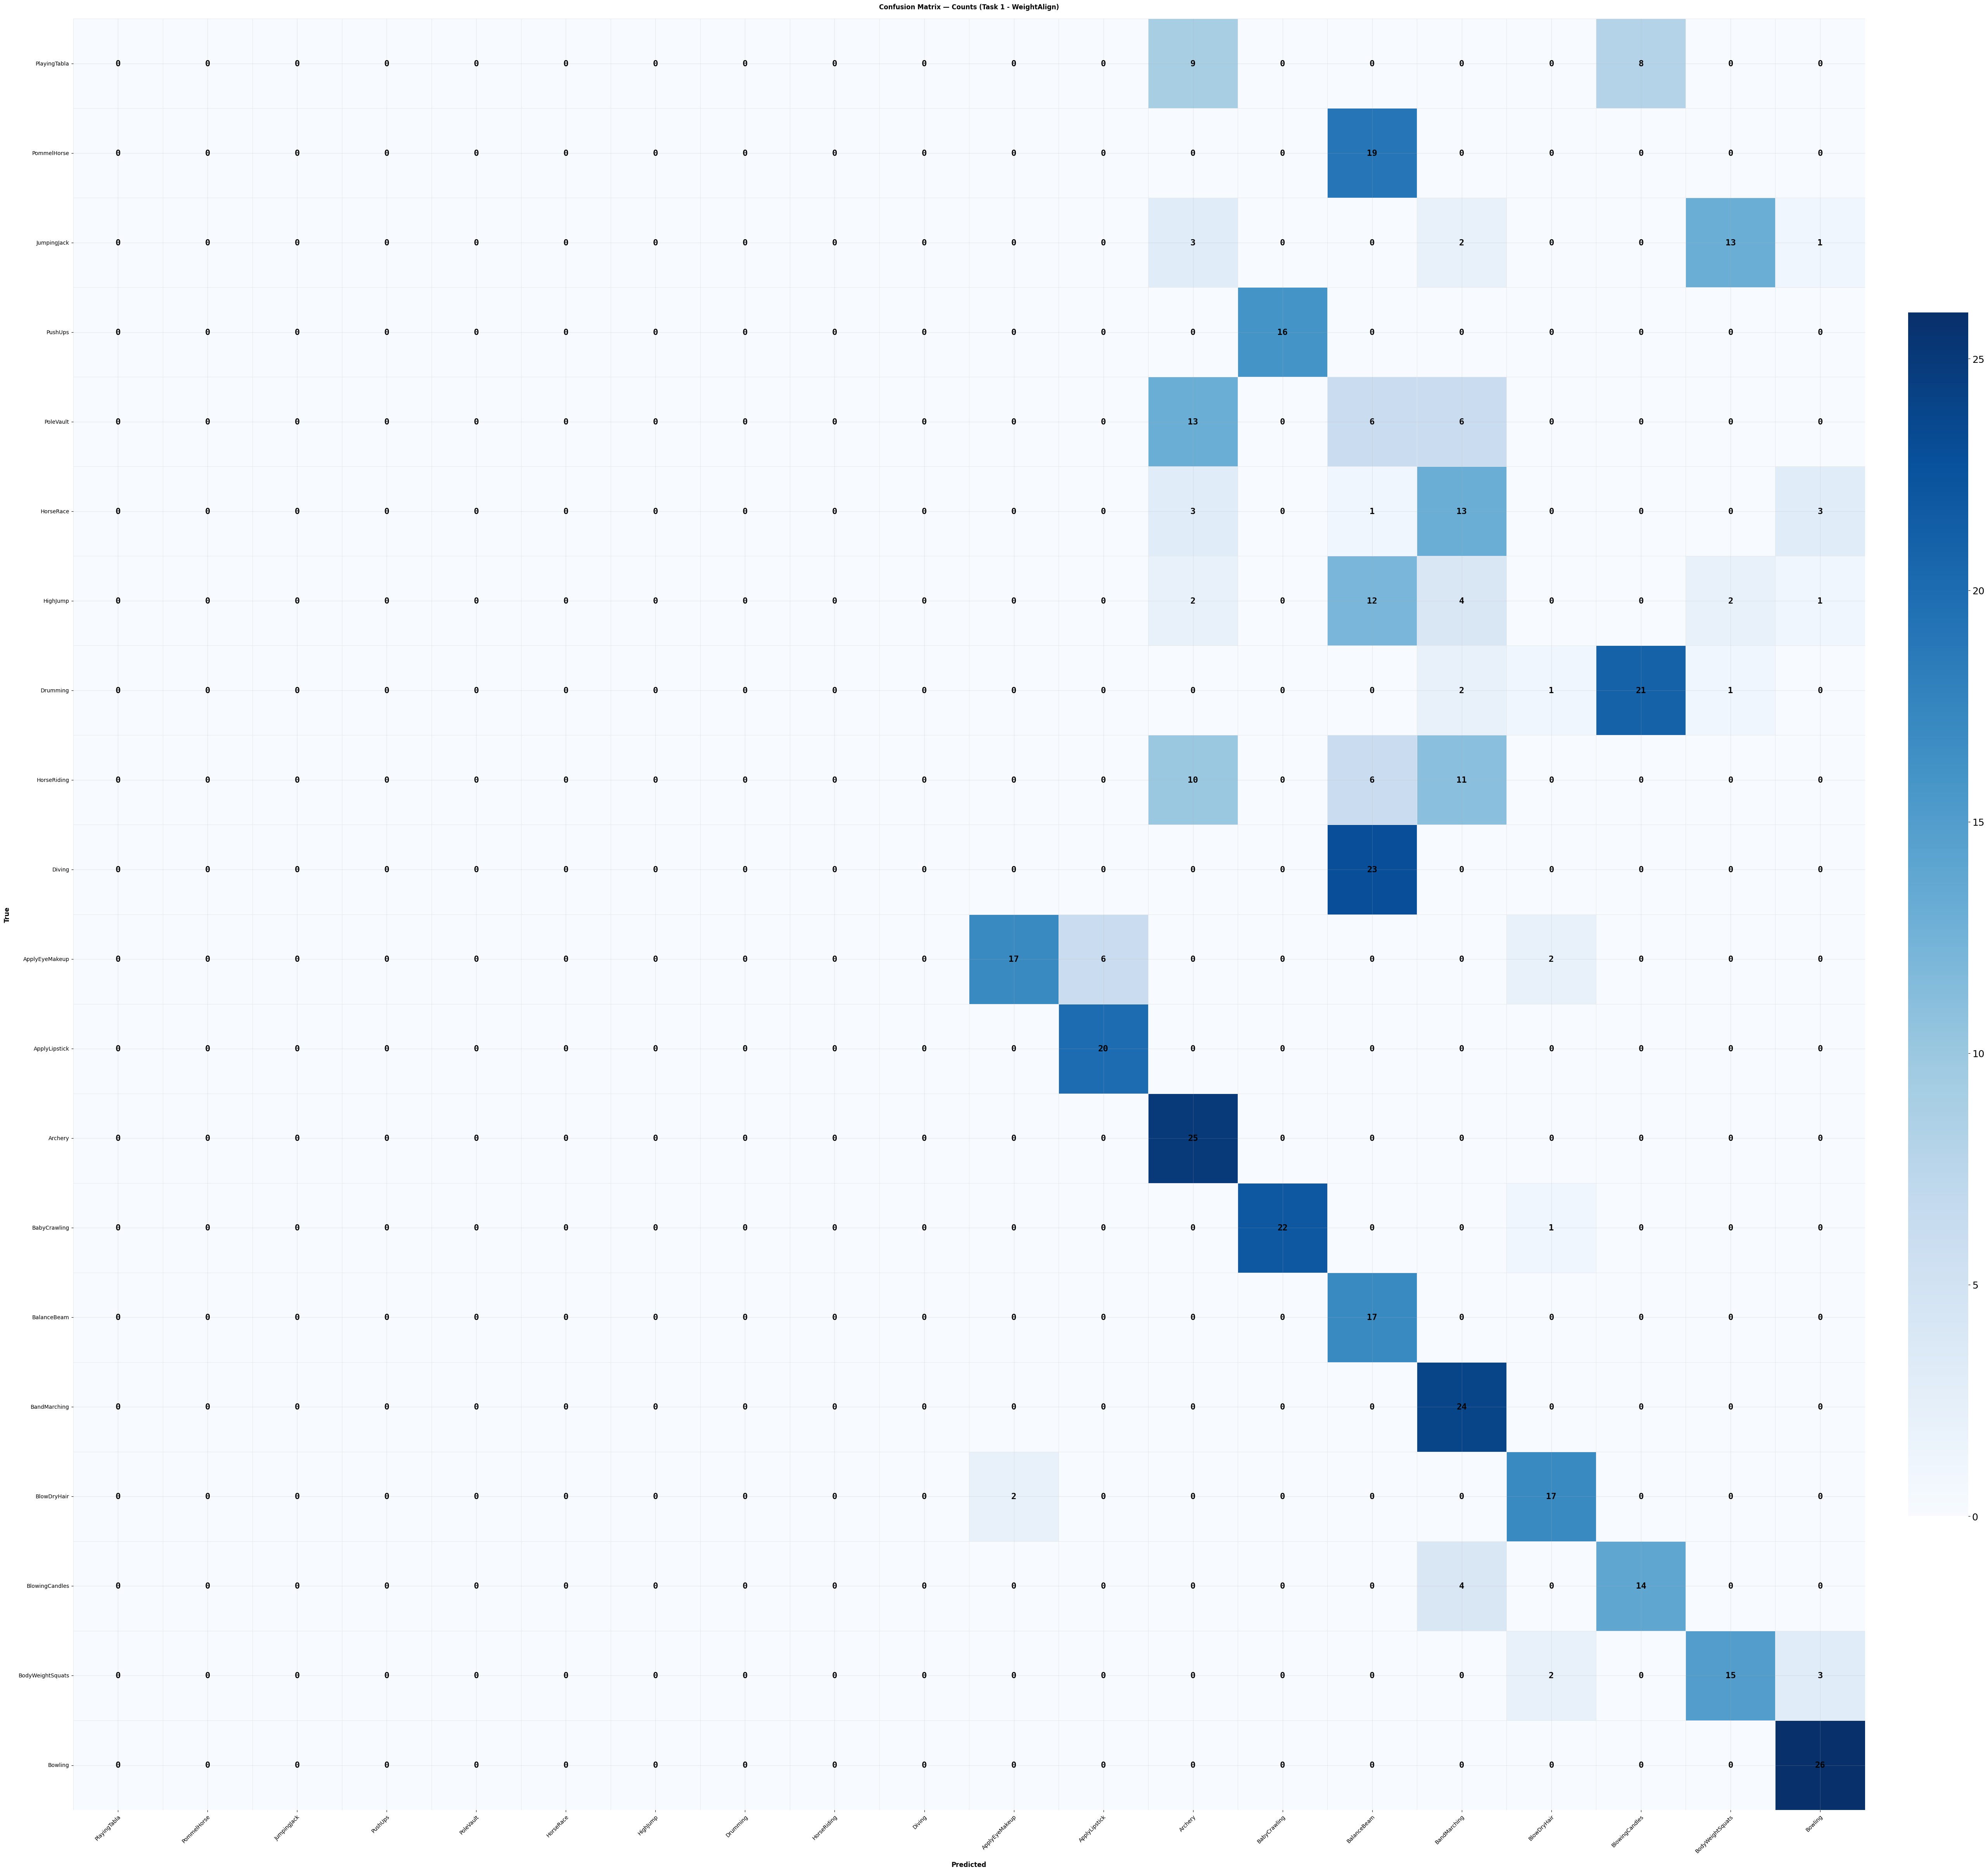

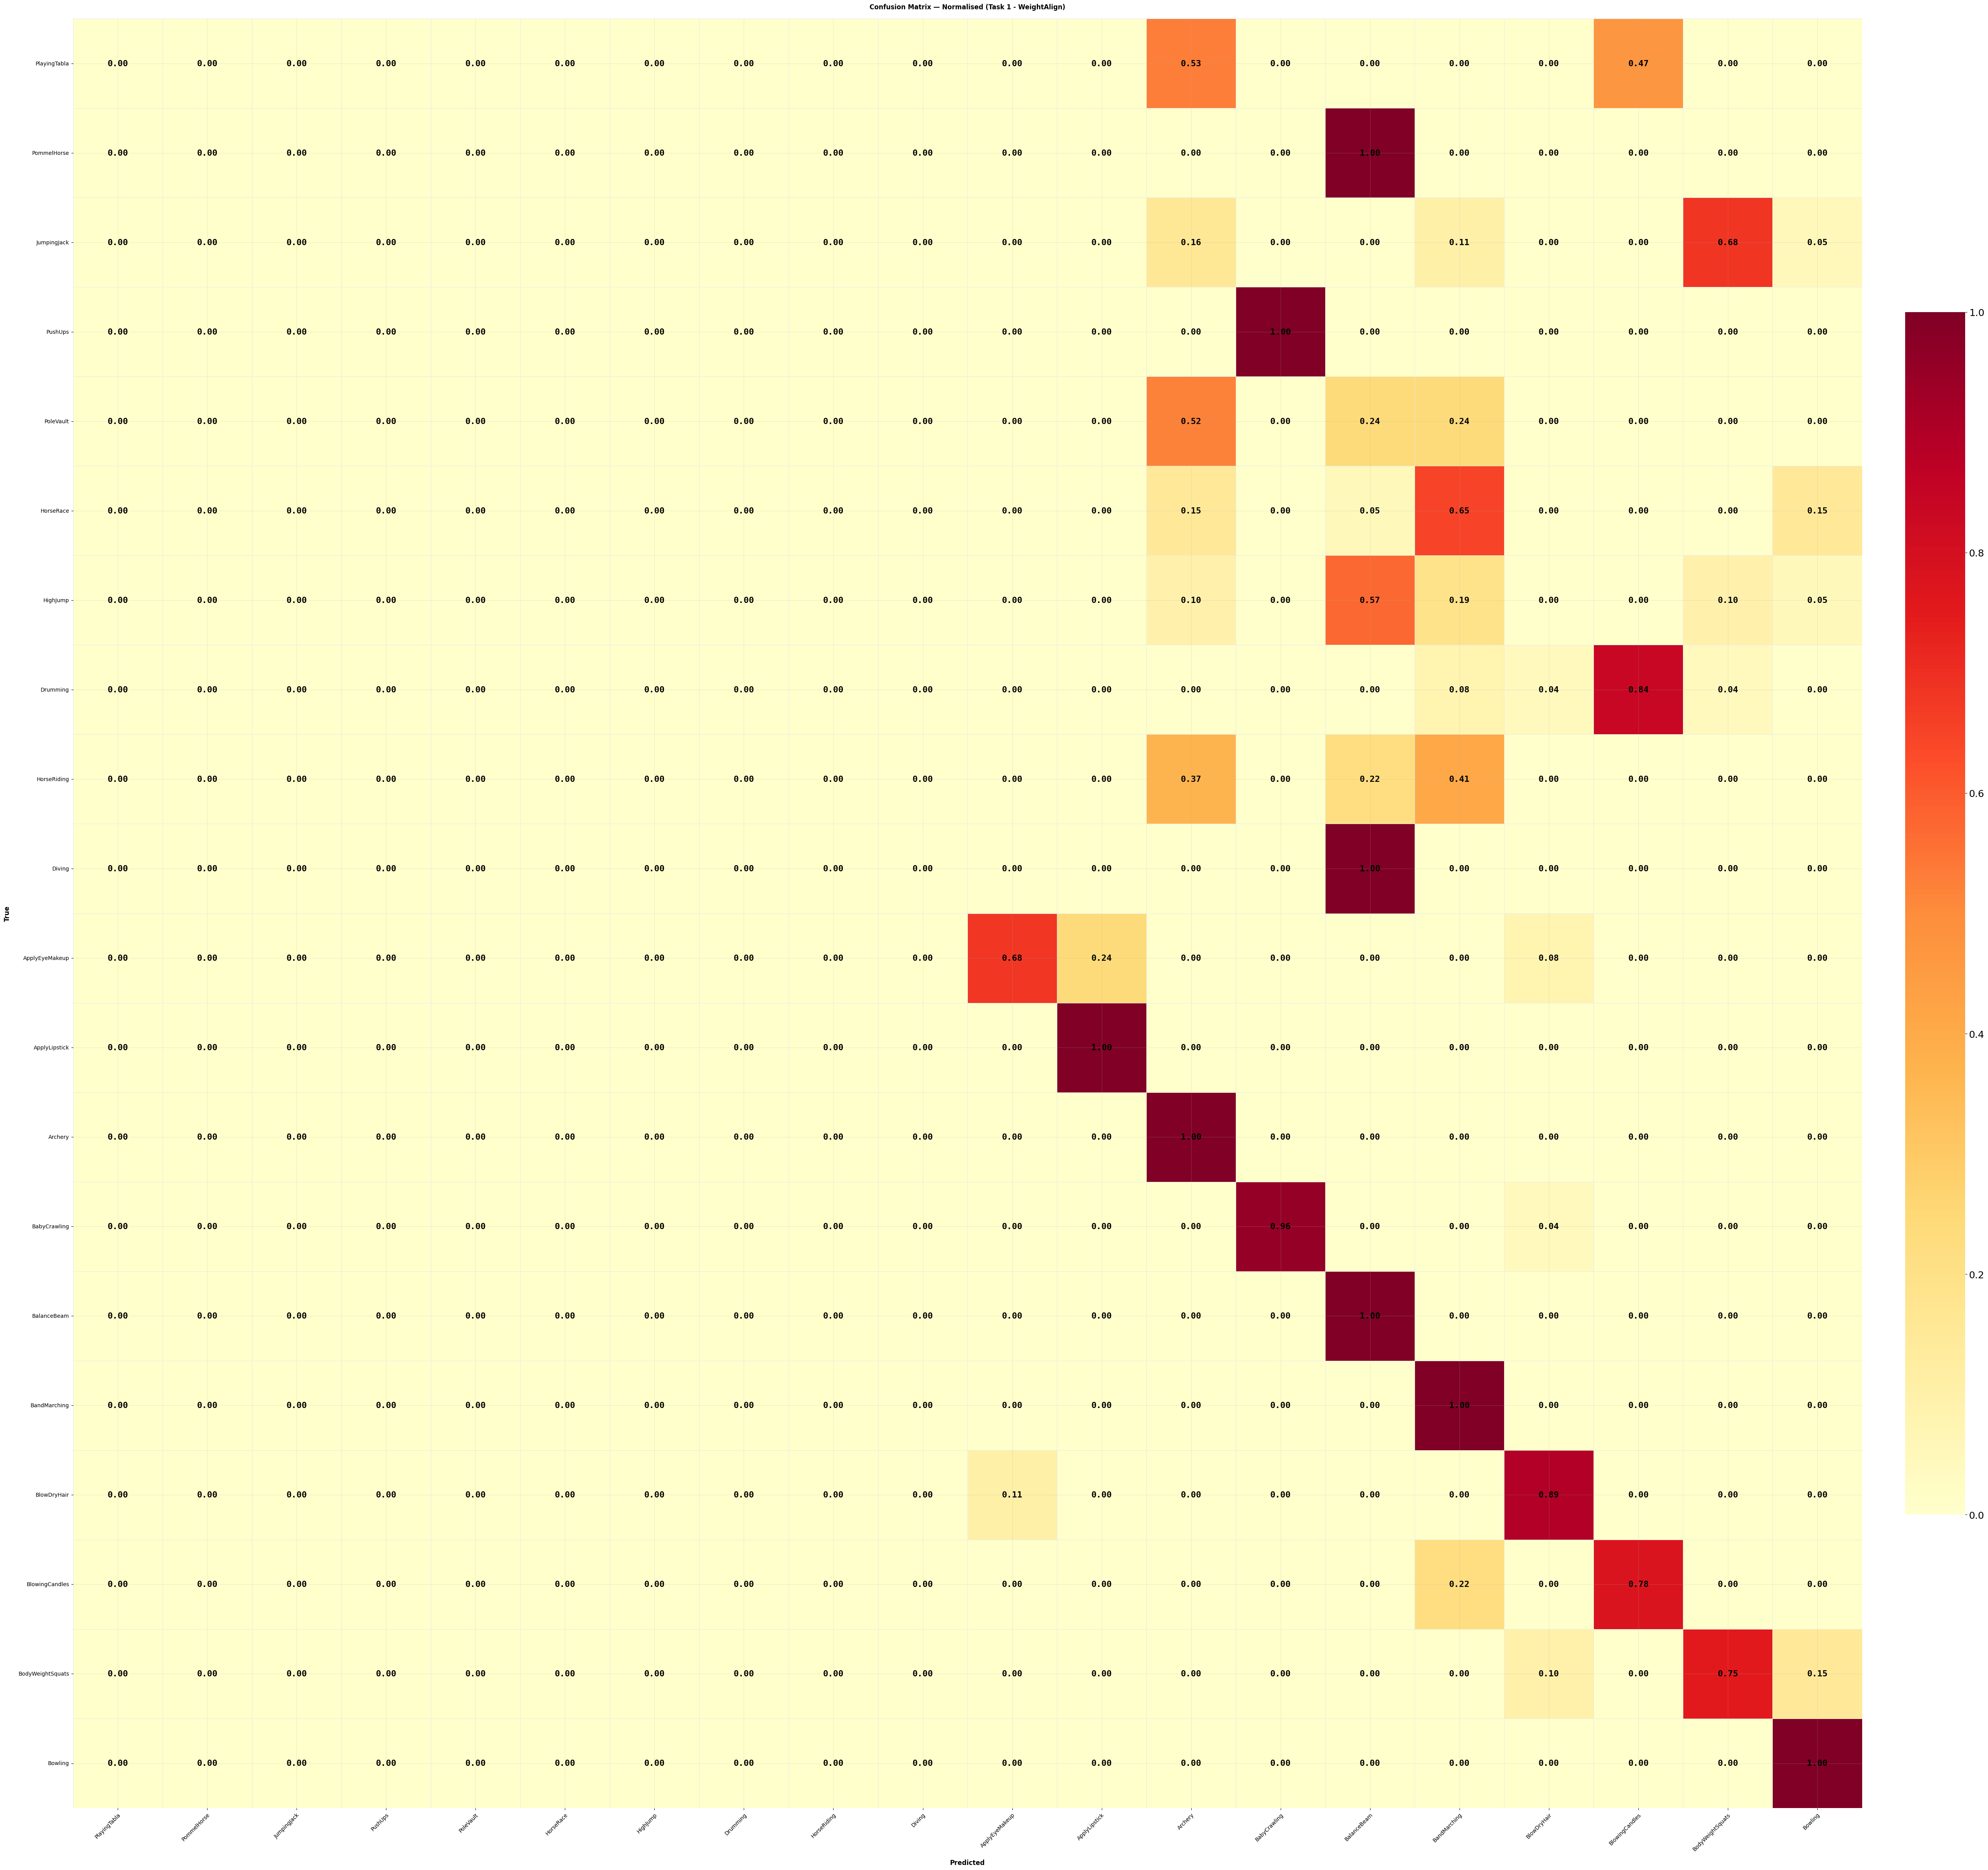

In [17]:
_, all_preds, all_labels = test_model(model_task1, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 1 - {ARM_NAME}",
)

In [18]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1)),
)


METRICS FOR 20 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.4592
  Precision : 0.2851
  Recall    : 0.4592
  F1-Score  : 0.3349

PER-CLASS REPORT 
                  precision    recall  f1-score   support

    PlayingTabla       0.00      0.00      0.00        17
     PommelHorse       0.00      0.00      0.00        19
     JumpingJack       0.00      0.00      0.00        19
         PushUps       0.00      0.00      0.00        16
       PoleVault       0.00      0.00      0.00        25
       HorseRace       0.00      0.00      0.00        20
        HighJump       0.00      0.00      0.00        21
        Drumming       0.00      0.00      0.00        25
     HorseRiding       0.00      0.00      0.00        27
          Diving       0.00      0.00      0.00        23
  ApplyEyeMakeup       0.89      0.68      0.77        25
   ApplyLipstick       0.77      1.00      0.87        20
         Archery       0.38      1.00      0.56        25
    BabyCrawling       0.58      

## **Task 2**

In [19]:
head_task2 = expand_head(head_task1, len(ALL_CLASSES_LIST))
model_task2 = ModelWrapper(head_task2).to(device)

In [20]:
results_baseline = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.0000  Loss=3.6671
  task1_only       -> Acc=0.9078  Loss=0.8630
  task2_only       -> Acc=0.0044  Loss=3.8966
  combined_t1      -> Acc=0.4592  Loss=2.2487
  combined_t2      -> Acc=0.3023  Loss=2.8173


In [21]:
set_seed(cfg.SEED)

head_task2, train_task2 = train_task(
    head_task2, task2_train, task2_y, task2_val, task2_vy, device,
    epochs=CL_EPOCHS, lr=CL_LR, wd=CL_WD, batch_size=CL_BATCH, label_smoothing=CL_LS,
    
    tag=ARM_KEY,
)
model_task2 = ModelWrapper(head_task2).to(device)

head_task2 = weight_align(head_task2, n_old=len(cfg.SELECTED_CLASSES) + len(cfg.TASK_1))
model_task2 = ModelWrapper(head_task2).to(device)

Epoch [1/15] | Train Acc: 0.6398 Loss: 1.7244 | Val Acc: 0.7468 Loss: 0.7717
  [weight_align] ep 01/15 | CE 1.7244
Epoch [2/15] | Train Acc: 0.9273 Loss: 0.8997 | Val Acc: 0.8165 Loss: 0.5635
Epoch [3/15] | Train Acc: 0.9768 Loss: 0.7564 | Val Acc: 0.7911 Loss: 0.6156
Epoch [4/15] | Train Acc: 0.9919 Loss: 0.7095 | Val Acc: 0.7975 Loss: 0.6611
Epoch [5/15] | Train Acc: 0.9960 Loss: 0.6841 | Val Acc: 0.8354 Loss: 0.6383
Epoch [6/15] | Train Acc: 0.9990 Loss: 0.6748 | Val Acc: 0.7785 Loss: 0.7791
Epoch [7/15] | Train Acc: 0.9990 Loss: 0.6664 | Val Acc: 0.8165 Loss: 0.6794
Epoch [8/15] | Train Acc: 1.0000 Loss: 0.6613 | Val Acc: 0.8291 Loss: 0.6929
Epoch [9/15] | Train Acc: 1.0000 Loss: 0.6595 | Val Acc: 0.8038 Loss: 0.7075
Epoch [10/15] | Train Acc: 1.0000 Loss: 0.6578 | Val Acc: 0.8165 Loss: 0.7155
Epoch [11/15] | Train Acc: 1.0000 Loss: 0.6576 | Val Acc: 0.8165 Loss: 0.7046
Epoch [12/15] | Train Acc: 1.0000 Loss: 0.6570 | Val Acc: 0.8165 Loss: 0.7138
Epoch [13/15] | Train Acc: 1.0000 L

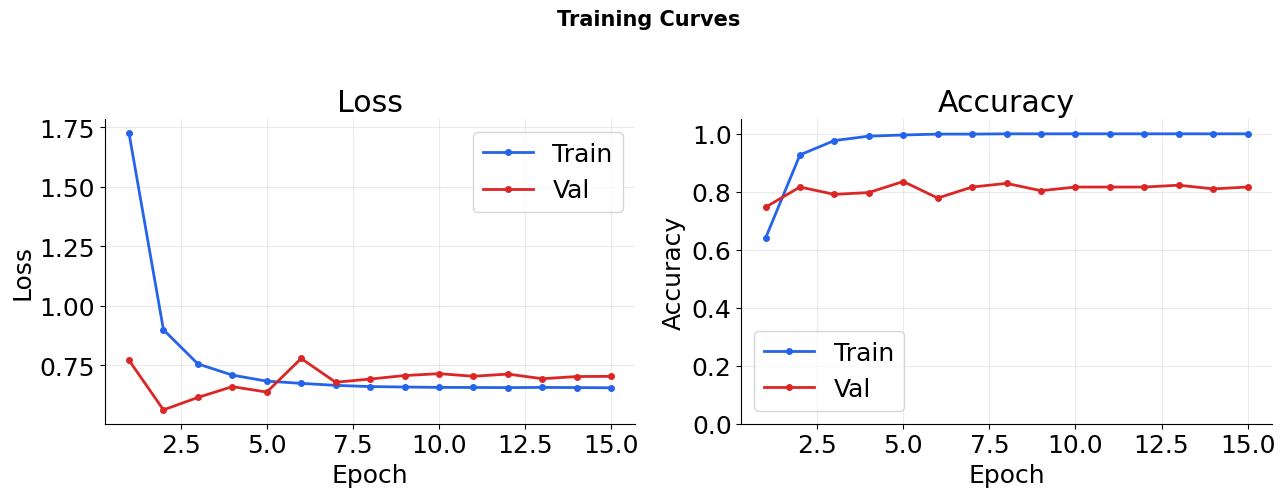

In [22]:
plot_training_results(train_task2)

In [23]:
results_after_t2 = evaluate_all_tasks(
    model            = model_task2,
    device           = device,
    base_loader      = base_test_loader,
    task_loaders     = [task1_test_loader, task2_test_loader],
    combined_loaders = [combined_test_loader, combined_test_loader2],
)

  base             -> Acc=0.0000  Loss=3.5607
  task1_only       -> Acc=0.0323  Loss=3.2033
  task2_only       -> Acc=0.8496  Loss=1.3738
  combined_t1      -> Acc=0.0163  Loss=3.3799
  combined_t2      -> Acc=0.3038  Loss=2.6877


Running Inference on Test Set...


Test Accuracy: 0.3038


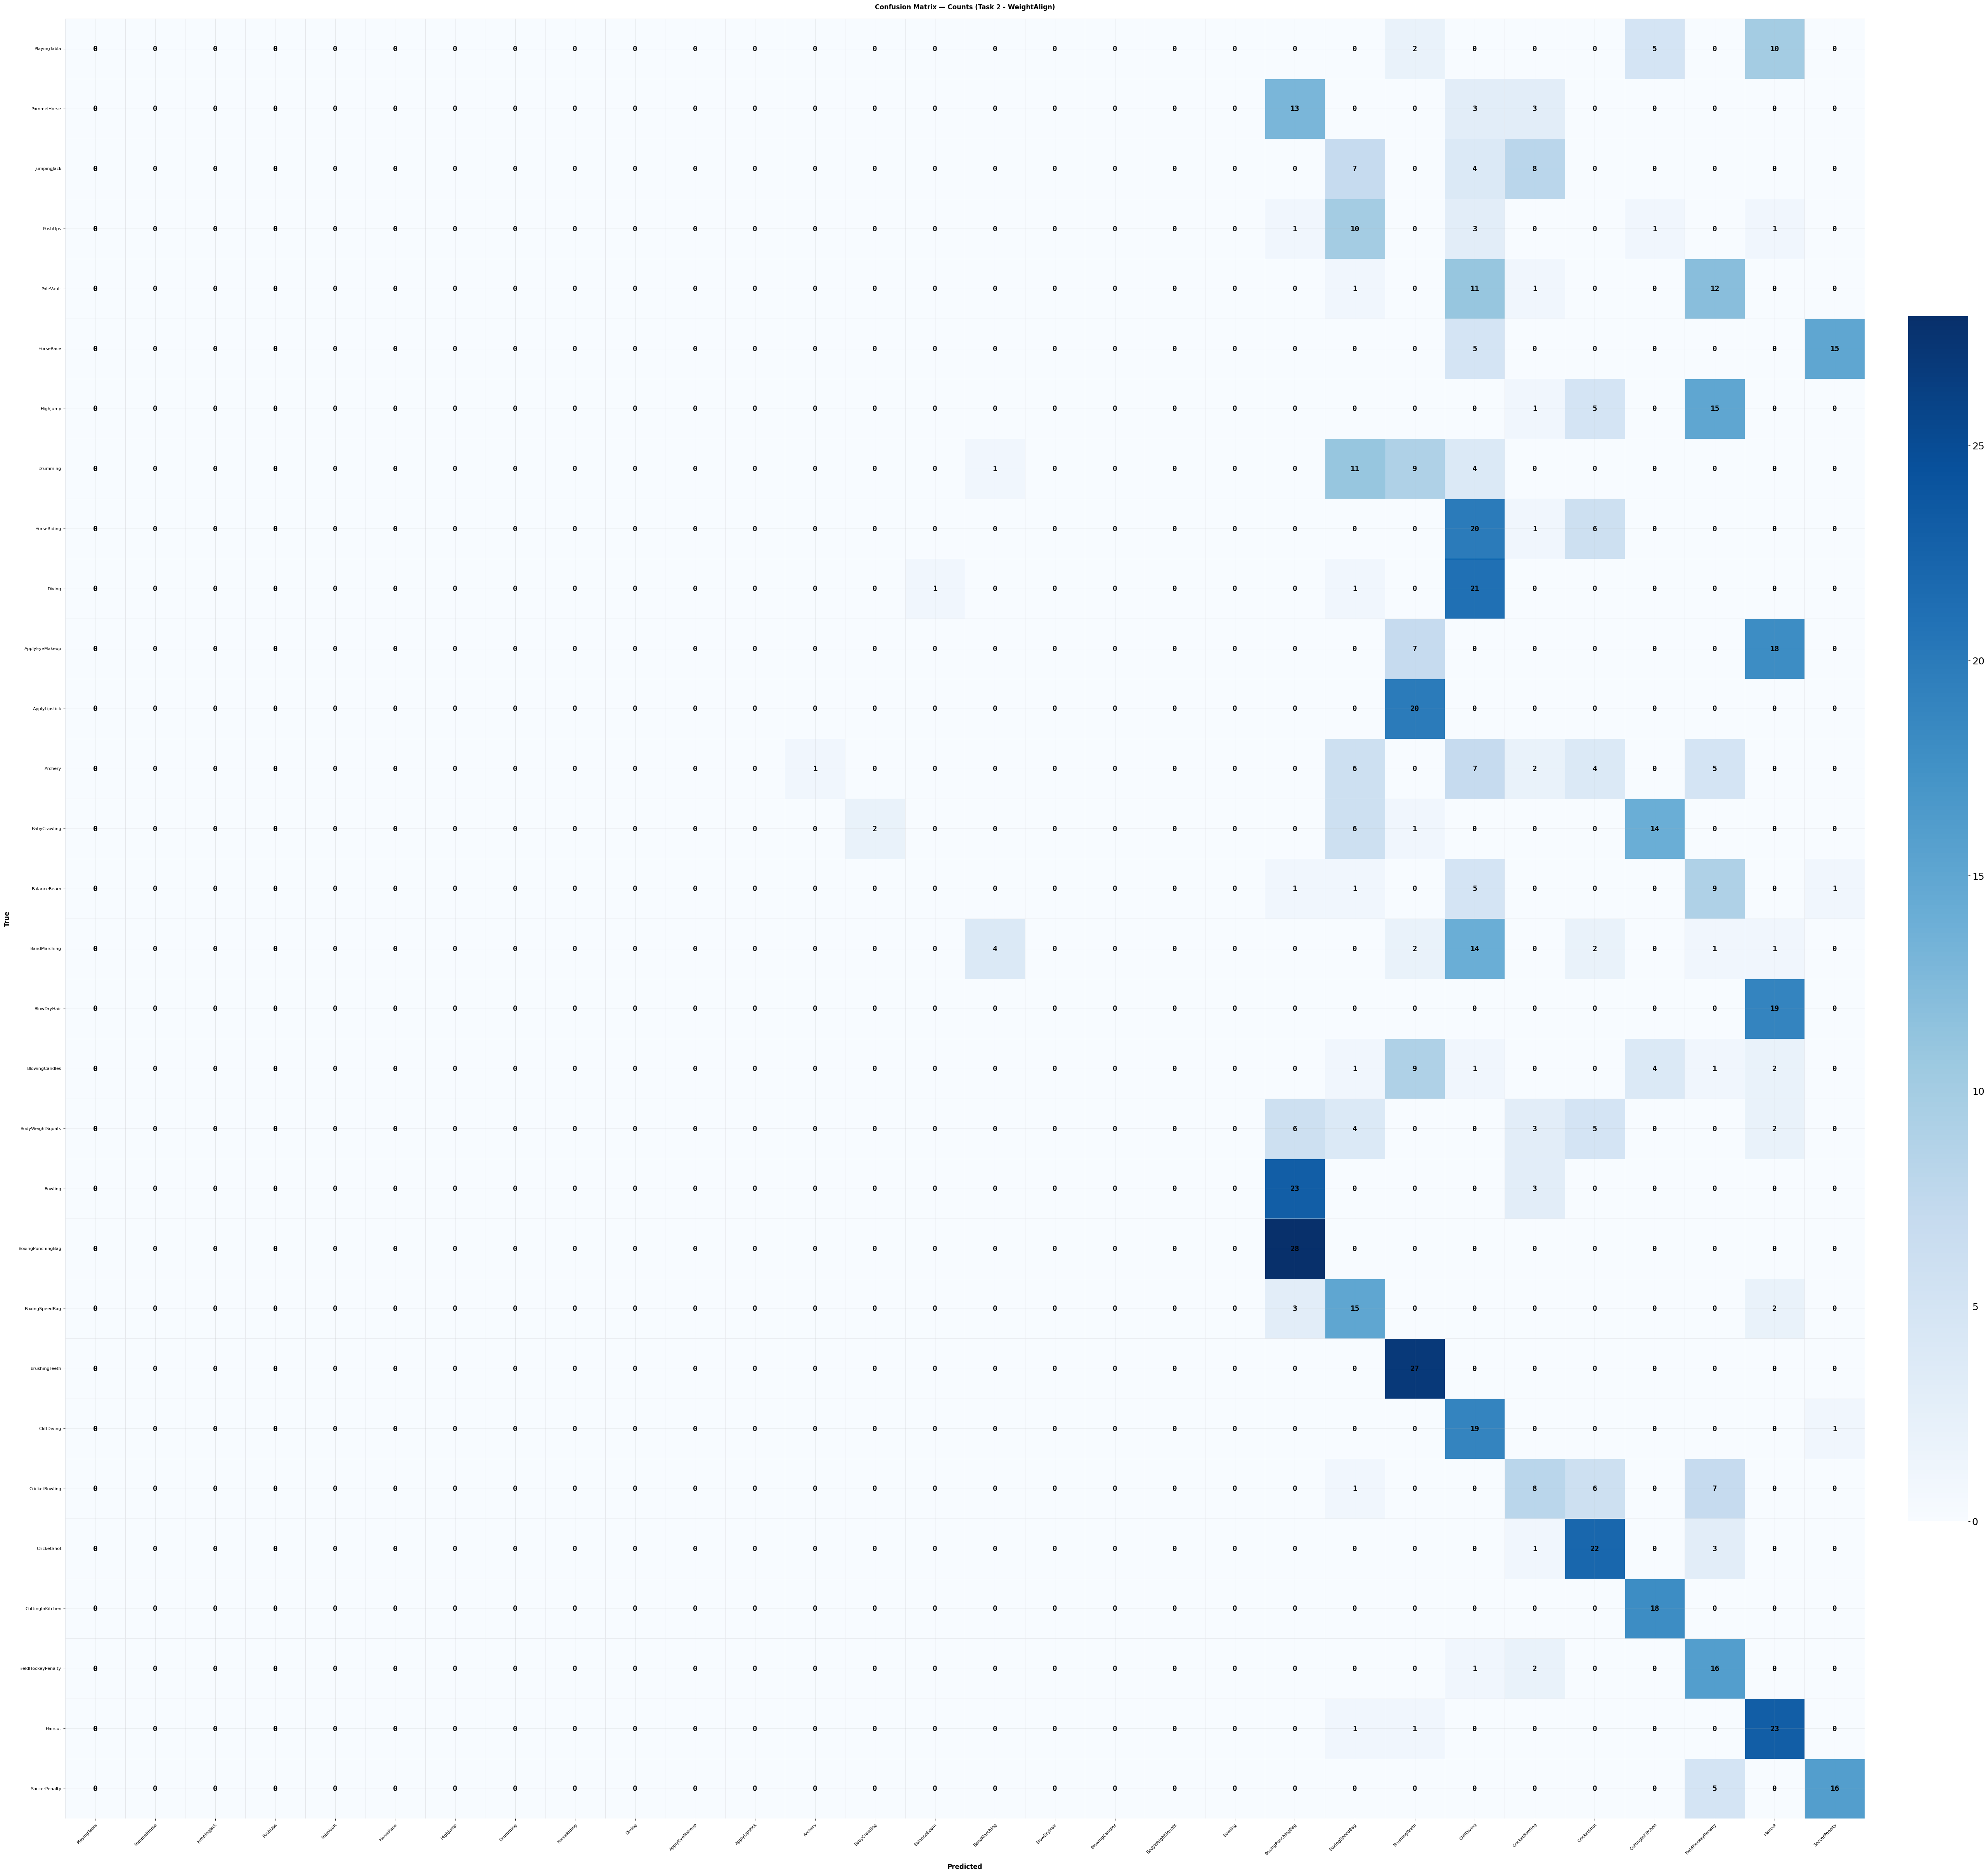

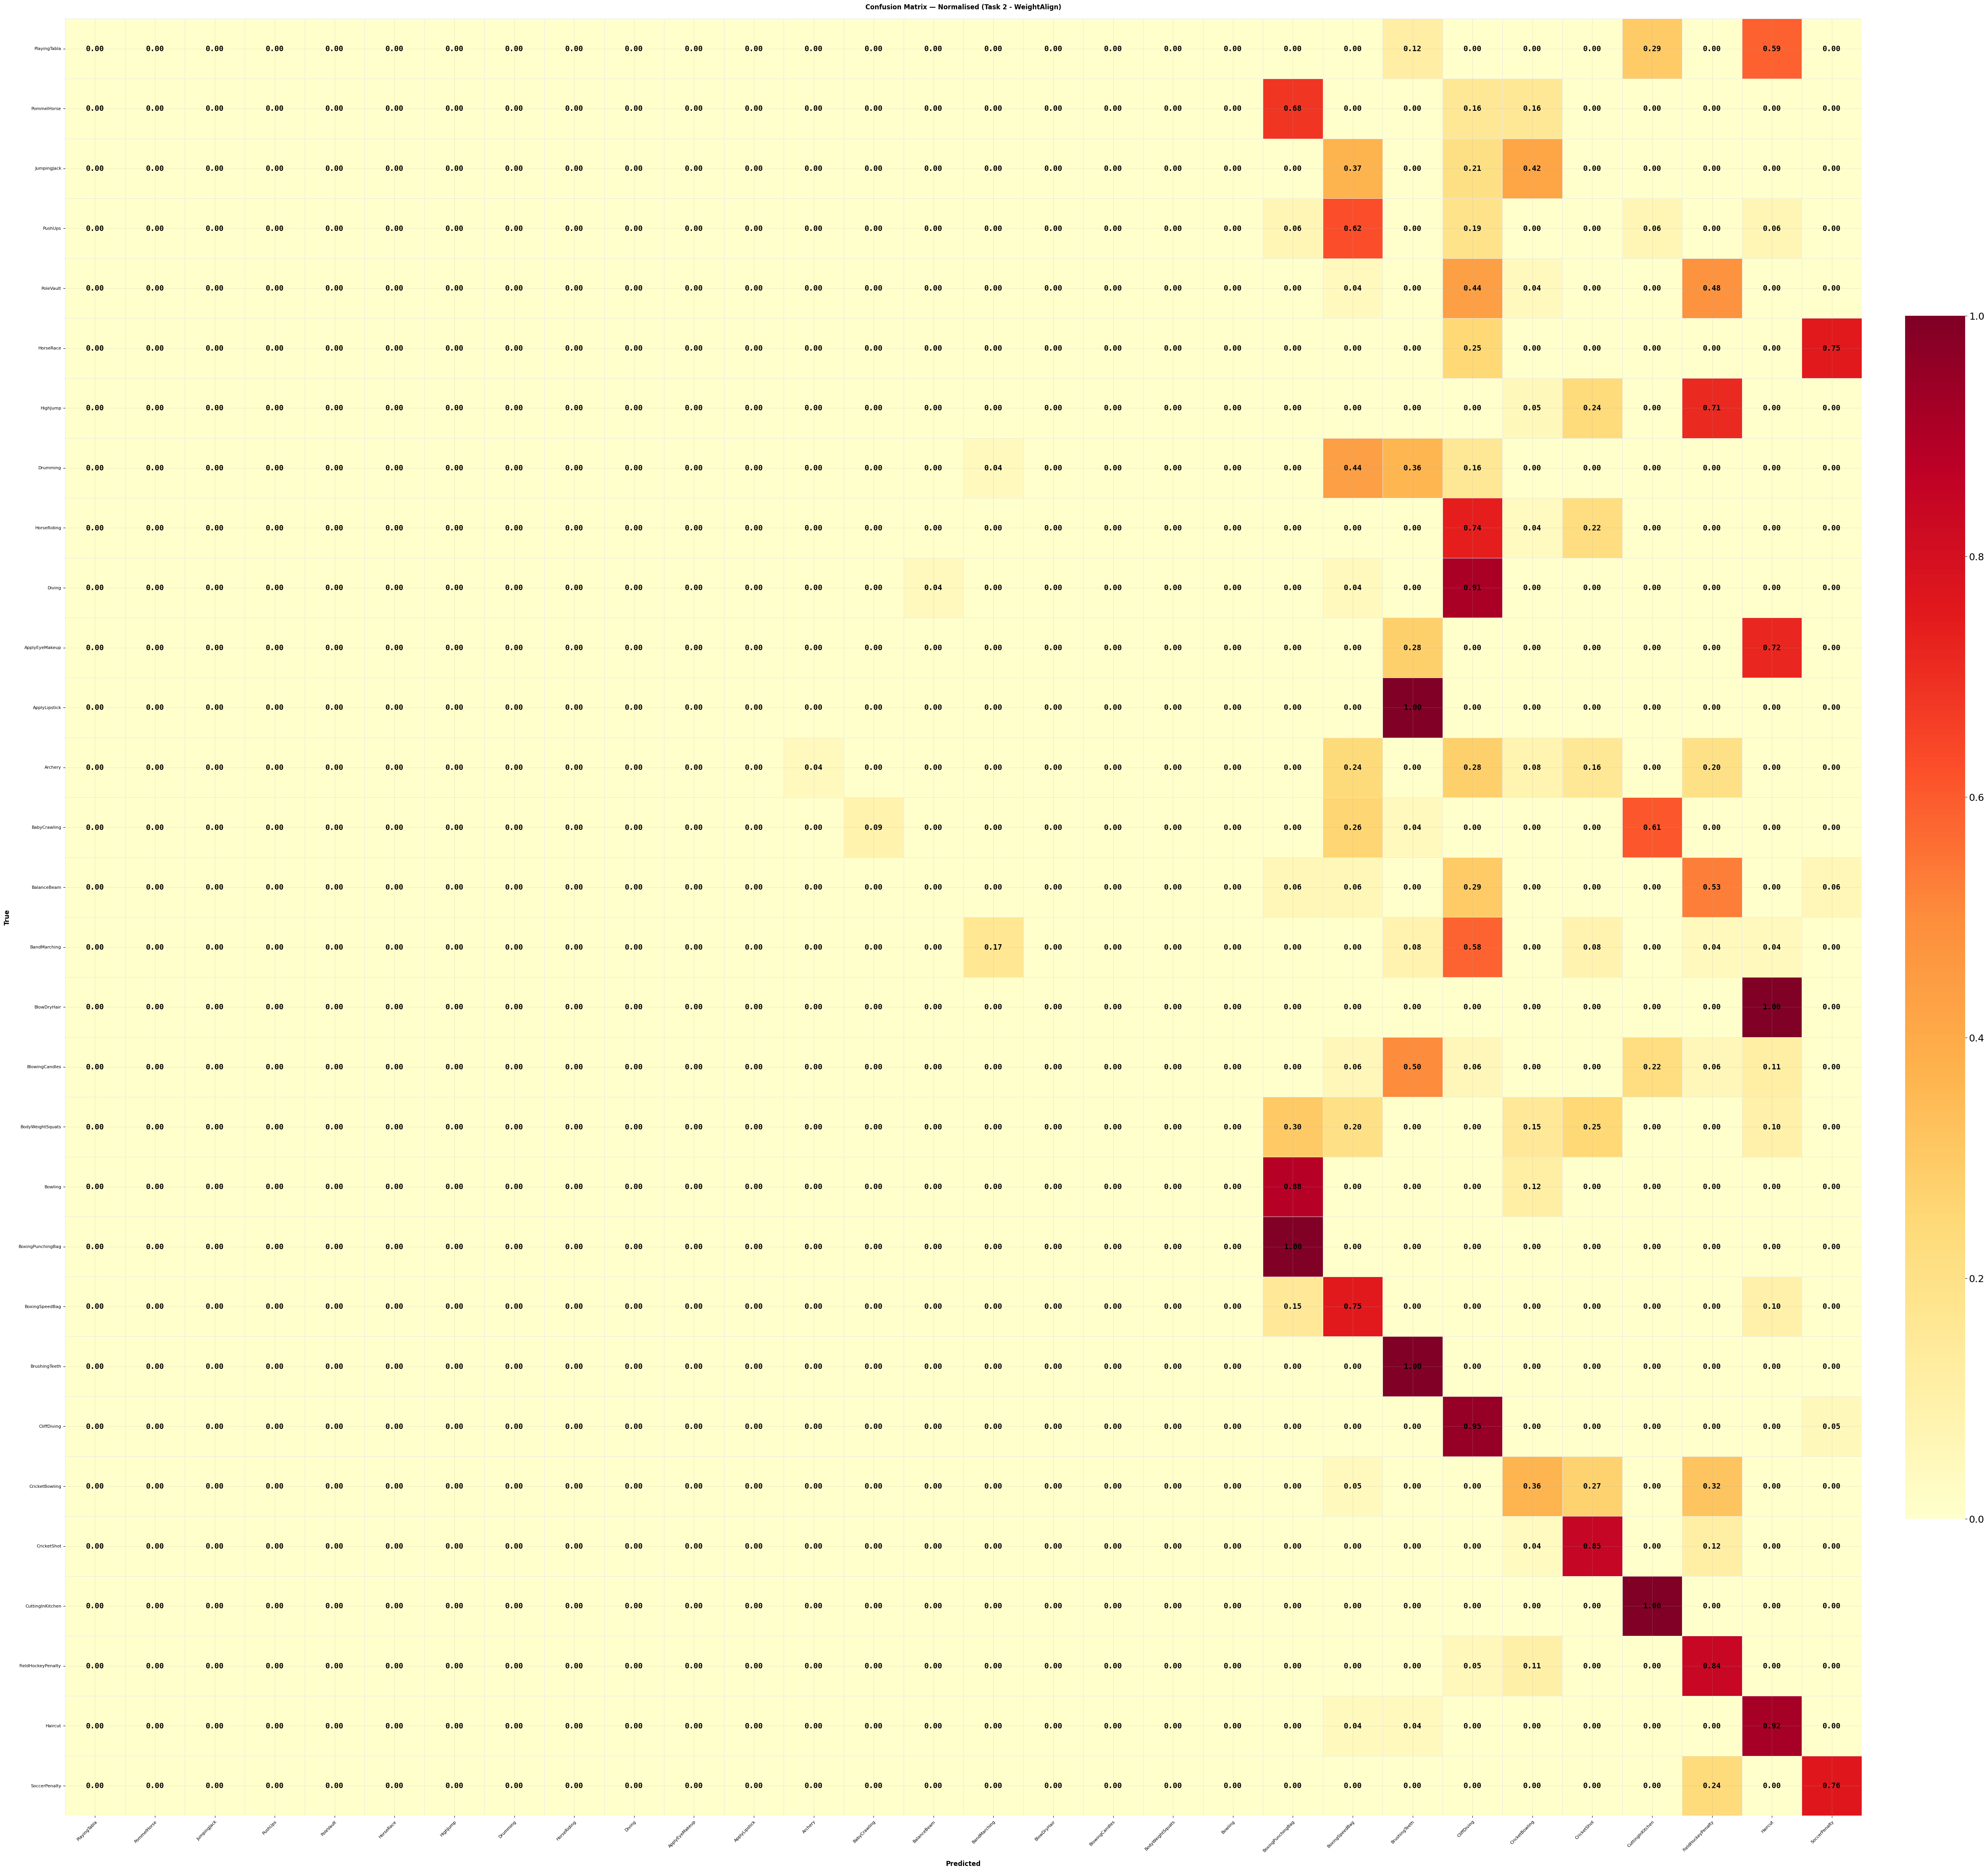

In [24]:
_, all_preds, all_labels = test_model(model_task2, combined_test_loader2, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = f"Task 2 - {ARM_NAME}",
)

In [25]:
print_detailed_metrics(
    all_labels   = all_labels,
    all_preds    = all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    split_old    = (0, len(cfg.SELECTED_CLASSES)),
    split_new    = (len(cfg.SELECTED_CLASSES), len(ALL_CLASSES_LIST)),
)


METRICS FOR 30 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.3038
  Precision : 0.2152
  Recall    : 0.3038
  F1-Score  : 0.1776

PER-CLASS REPORT 
                    precision    recall  f1-score   support

      PlayingTabla       0.00      0.00      0.00        17
       PommelHorse       0.00      0.00      0.00        19
       JumpingJack       0.00      0.00      0.00        19
           PushUps       0.00      0.00      0.00        16
         PoleVault       0.00      0.00      0.00        25
         HorseRace       0.00      0.00      0.00        20
          HighJump       0.00      0.00      0.00        21
          Drumming       0.00      0.00      0.00        25
       HorseRiding       0.00      0.00      0.00        27
            Diving       0.00      0.00      0.00        23
    ApplyEyeMakeup       0.00      0.00      0.00        25
     ApplyLipstick       0.00      0.00      0.00        20
           Archery       1.00      0.04      0.08        25
     

## **Latent Space**

In [26]:
preds_emb, labels_emb = predict_head(head_task2, CACHE, [0, 1, 2], device)

res_emb = report_accuracy(preds_emb, labels_emb, TASK_CLASSES, TASK_NAMES, class_to_idx,
                          title=f"FINAL - EMBEDDINGS ({ARM_NAME})")


  FINAL - EMBEDDINGS (WeightAlign)
  Base          0.00%   (212 clips, 10 classes)
  Task1         3.23%   (217 clips, 10 classes)
  Task2        84.96%   (226 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     30.38%   (655 clips, all classes)
  mean/task    29.39%


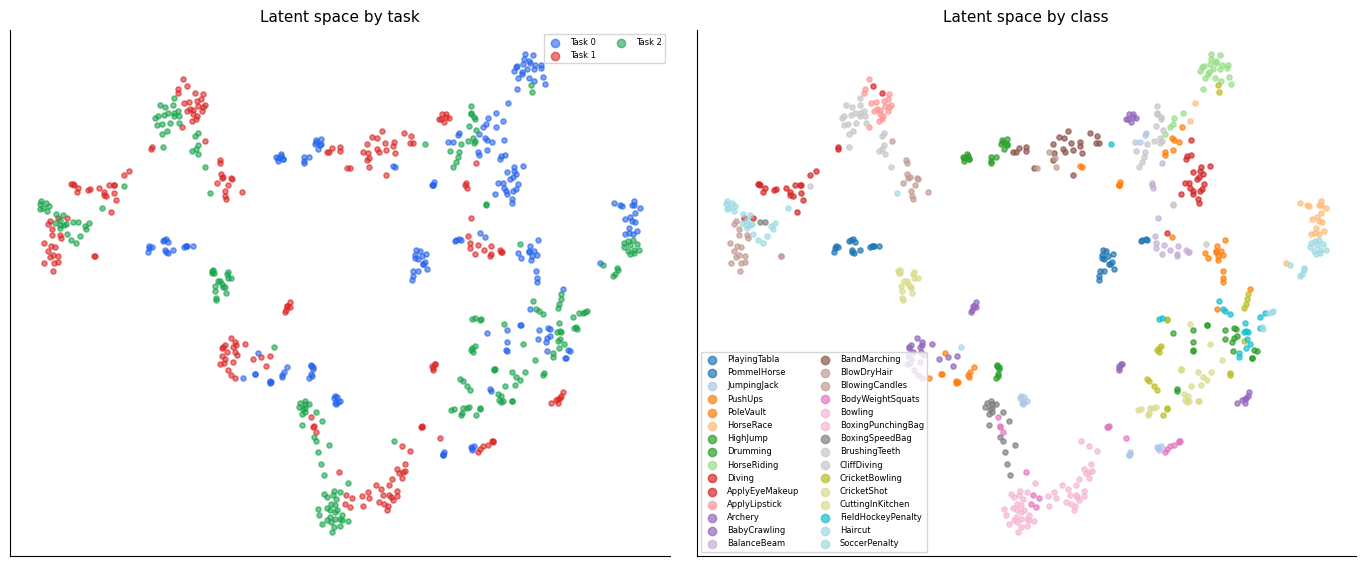

In [27]:
xy, lab = project_head_space(head_task2, CACHE, [0, 1, 2], device, seed=cfg.SEED)
task_of = {class_to_idx[c]: t for t, g in enumerate(TASK_CLASSES) for c in g}

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
plot_latent_space(xy, lab, ALL_CLASSES_LIST, task_of=task_of,
                  title="Latent space by task", ax=ax[0])
plot_latent_space(xy, lab, ALL_CLASSES_LIST,
                  title="Latent space by class", ax=ax[1])
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/latent_{ARM_KEY}.png", dpi=150, bbox_inches="tight")
plt.show()

## **Evaluation on Real Images**

In [28]:
if not clips_available(TASK_ROOTS, "test"):
    print("Raw clips not found. Re-run the Preprocess cell to evaluate on real images.")
    res_real = None
else:
    backbone = load_frozen_backbone(
        device, ResNet50LSTMTeacher, cfg.RESNET50_PATH,
        hidden_size=cfg.TEACHER_HIDDEN, num_classes=len(cfg.SELECTED_CLASSES),
        dropout_p=cfg.DROPOUT_P, remap_fn=remap_teacher_checkpoint,
    )
    full_model = FullModel(backbone, head_task2, backbone_dim=cfg.BACKBONE_DIM).to(device)

    real_loader = clip_loaders(TASK_ROOTS, TASK_CLASSES, class_to_idx, "test",
                               batch_size=cfg.BATCH_SIZE, num_workers=cfg.NUM_WORKERS)[1]
    preds_real, labels_real = predict(full_model, real_loader, device)

    res_real = report_accuracy(preds_real, labels_real, TASK_CLASSES, TASK_NAMES,
                               class_to_idx, title=f"FINAL - REAL IMAGES ({ARM_NAME})")

  Dropped 53 num_batches_tracked buffer(s).

  FINAL - REAL IMAGES (WeightAlign)
  Base          2.81%   (356 clips, 10 classes)
  Task1         4.72%   (360 clips, 10 classes)
  Task2        82.04%   (373 clips, 10 classes)
  ----------------------------------------------------------
  COMBINED     30.58%   (1089 clips, all classes)
  mean/task    29.86%


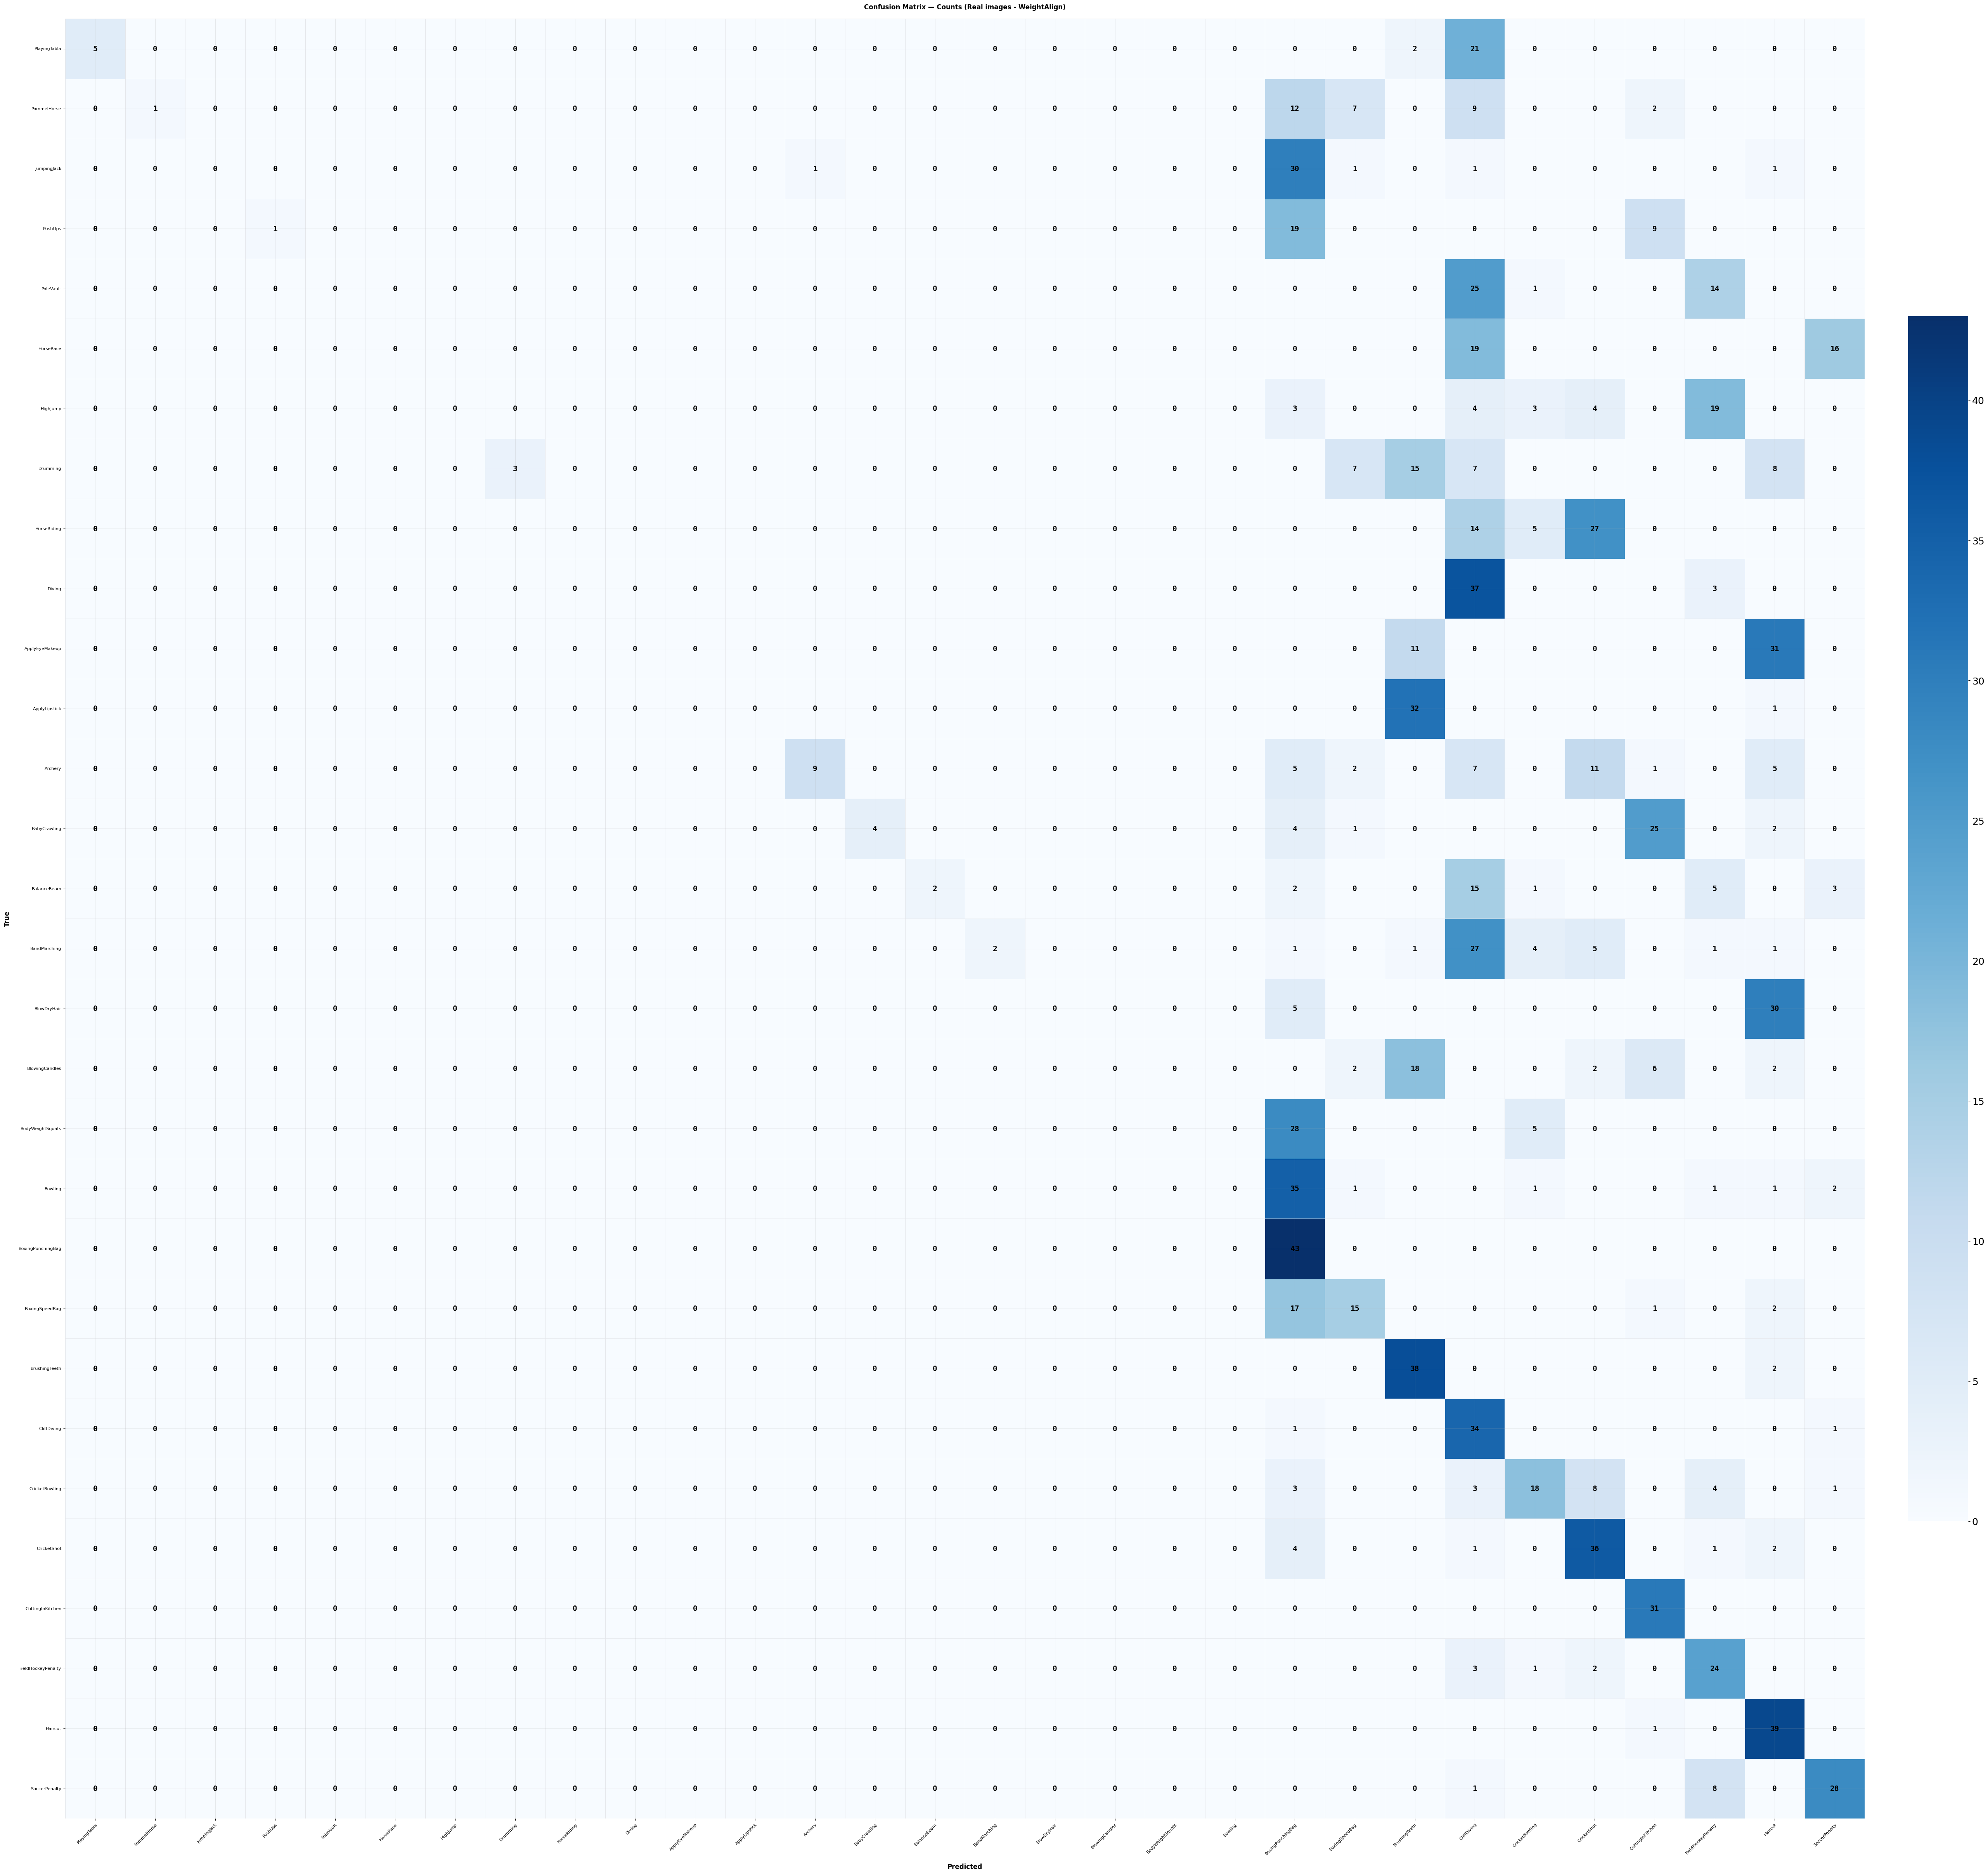

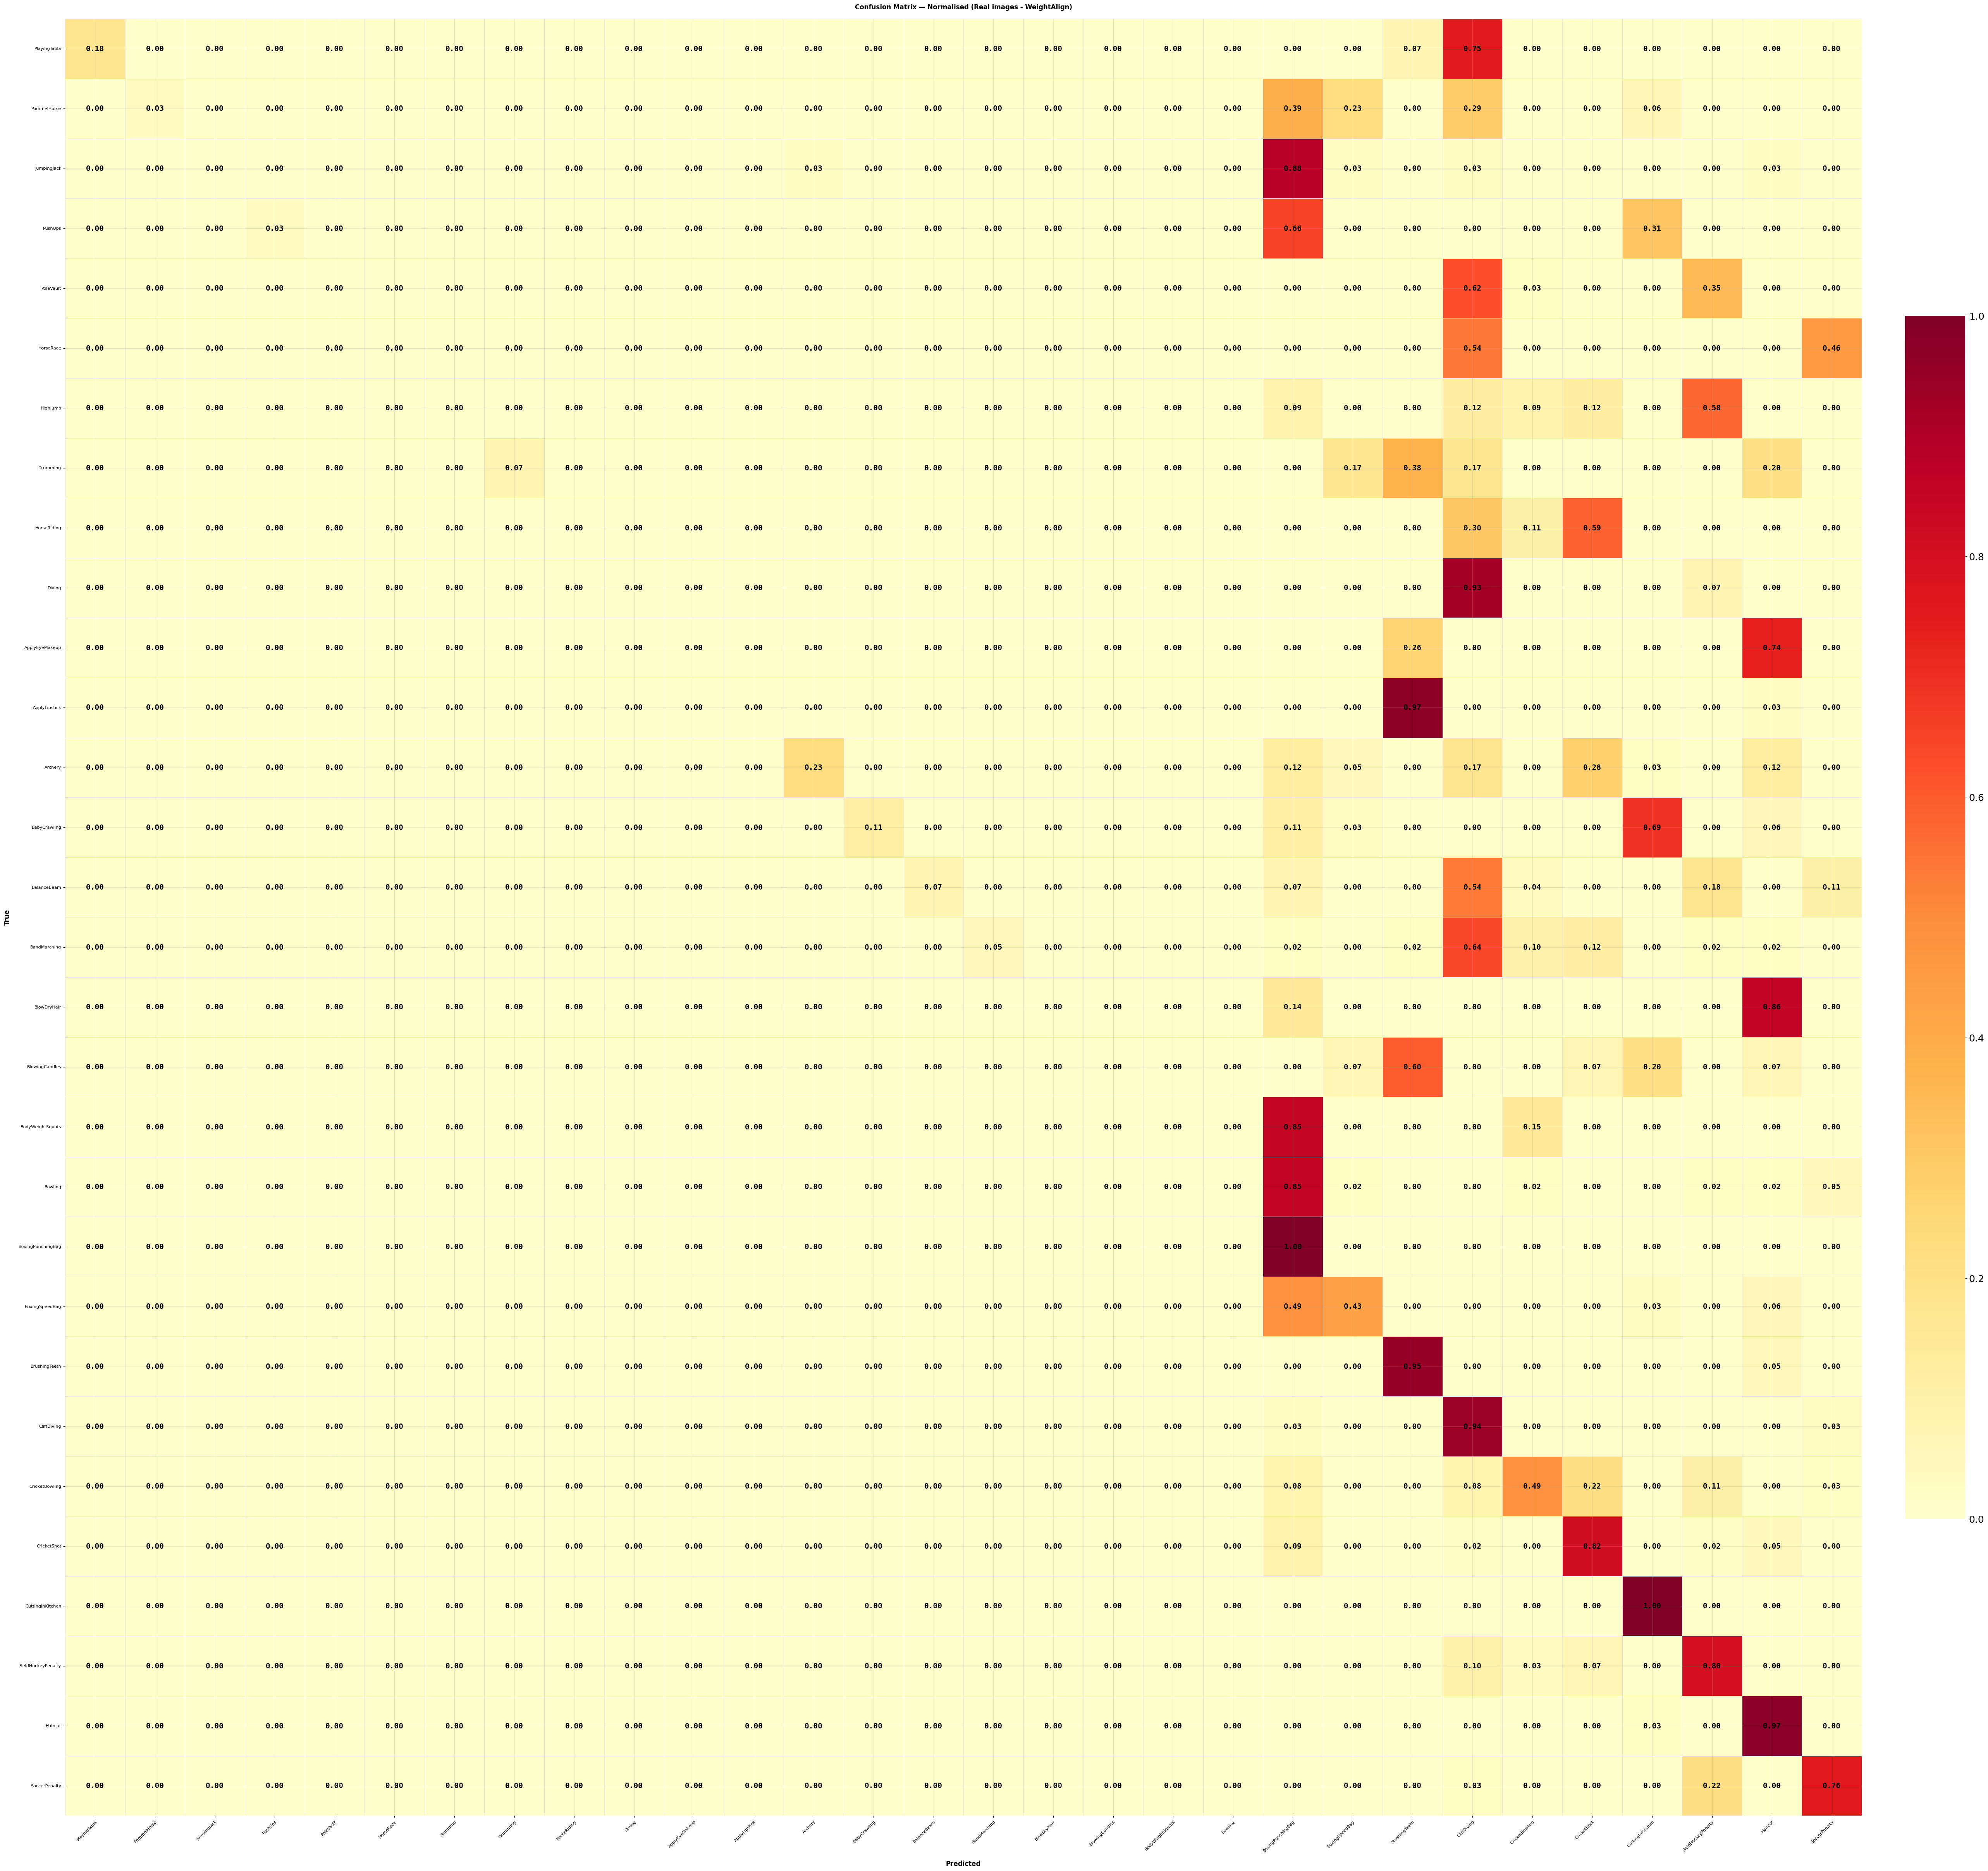


  EMBEDDINGS vs REAL IMAGES
  Split          embeddings   real images     diff
  ----------------------------------------------------------
  Base                0.00%         2.81%   +2.81%
  Task1               3.23%         4.72%   +1.50%
  Task2              84.96%        82.04%   -2.92%
  ----------------------------------------------------------
  COMBINED           30.38%        30.58%   +0.20%
  Paths agree.


In [29]:
if res_real is not None:
    plot_confusion_matrix(
        labels_real, preds_real,
        num_classes  = len(ALL_CLASSES_LIST),
        classes_list = ALL_CLASSES_LIST,
        name         = f"Real images - {ARM_NAME}",
    )

    compare_embeddings_vs_real(res_emb, res_real, TASK_NAMES)

## **Save**

In [ ]:
# per-task rows, captured before Task 2 mutates head_task1 in place
ROWS = [
    {0: eval_head(head_base, *task_split(CACHE, 0, "test"), device)},
    {0: results_after_t1["base"]["accuracy"],
     1: results_after_t1["task1_only"]["accuracy"]},
    {0: results_after_t2["base"]["accuracy"],
     1: results_after_t2["task1_only"]["accuracy"],
     2: results_after_t2["task2_only"]["accuracy"]},
]
BYTES_PER_CLASS = buffer_bytes_per_class(buffer, 15) if "buffer" in dir() else 0

R, m = save_arm_result(f"{cfg.RESULTS_DIR}/stage1_arm_{ARM_KEY}.json",
                       ARM_NAME, ROWS, TASK_NAMES, BYTES_PER_CLASS,
                       config=ARM_CONFIG, ceiling=None)
cl_report(R, ARM_NAME, TASK_NAMES)
torch.save(head_task2.state_dict(), f"{cfg.CKPT_DIR}/head_{ARM_KEY}.pt")

with open(f"{cfg.RESULTS_DIR}/stage1_final_{ARM_KEY}.json", "w") as f:
    json.dump({"embeddings": res_emb, "real_images": res_real}, f, indent=2, default=float)